In [ ]:
!pip install tcrgnn

In [1]:
from tcrgnn import generate_edges_from_pdb_file, EdgeGenConfig

cfg = EdgeGenConfig() # You can customize the configuration if needed, but the default is what we used for our research experiments

In [45]:
from tcrgnn import generate_edges_from_tar,generate_edges_from_tar_dir

In [46]:
generate_edges_from_tar_dir('/scratch/project/tcr_ml/colabfold/results_2/prediction/temp_sle','/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_sle/raw',cfg)

[PosixPath('/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_sle/raw/part_table_BFI-0009804.tar.gz')]

In [47]:
from tcrgnn import load_pca_encoding
pca_encoding = load_pca_encoding("/scratch/project/tcr_ml/gnn_release/AAidx_PCA_2024.txt")
pca_encoding

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
A,-0.119337,4.766417,17.116718,2.295739,3.153466,3.641931,-2.857472,-0.510985,3.842872,-1.553891,0.760858,1.727918,2.143332,2.080794
L,17.827236,2.574882,11.241191,6.959181,-1.981687,2.180934,-0.098418,1.090348,0.559656,5.462775,7.368277,-1.595037,0.661500,0.083453
R,-8.188429,-15.255091,-1.522583,0.076711,-7.413312,-8.284450,-6.454110,-5.305068,-0.090436,-5.391594,5.400477,-1.503589,-2.789434,-0.039869
K,-11.832051,-13.376451,5.349272,1.943336,-5.254241,-2.259015,-3.690758,0.058316,-1.170751,9.122410,-4.000843,2.100945,-0.789188,3.080768
N,-15.229827,-0.084290,-3.488524,-6.198218,-1.827574,1.607748,4.176737,5.400174,-0.964957,4.007921,1.773937,-1.337021,-4.847988,-3.707884
M,16.174029,-4.974744,3.197186,-1.917002,6.432085,4.222104,-5.937735,4.277950,-0.505234,-3.175196,-3.868715,-6.915054,-2.011987,2.902042
D,-18.214603,-3.286554,-0.400137,-1.904439,4.706532,4.241386,9.203848,-2.939339,-1.991538,-2.311474,1.381515,-1.929361,-3.442823,5.299531
F,19.523669,-0.291606,-3.964076,1.787112,-2.300718,3.777835,1.369979,2.015799,-0.562367,-1.618873,3.587535,-1.685901,-0.189207,-3.736868
C,8.263782,8.355437,-5.918452,-14.414202,12.698391,-6.393775,-3.524156,-4.560058,-2.210811,4.122490,2.415289,0.575655,1.107817,-0.316855
P,-16.669545,11.992157,-16.756806,19.067663,6.366500,-0.264777,-4.297000,0.456891,-0.831621,0.545217,0.335688,0.279900,-0.296780,0.280335


In [48]:
from pathlib import Path
from tcrgnn import generate_graphs_from_edge_dir_gz, generate_graphs_from_edge_dir

base_dir = Path("/scratch/project/tcr_ml/gnn_release/test_data_v2/temp_sle/raw")

# # # Loop over all .tar.gz files
for tar_file in base_dir.glob("*.tar.gz"):
    print(f"Processing: {tar_file}")
    generate_graphs_from_edge_dir_gz(
        tar_file,
        pca_encoding,
        label=0,
        save_to_disk=True,
        filename=tar_file.with_suffix("").with_suffix("").with_suffix(".pt")
    )
# generate_graphs_from_edge_dir("/scratch/project/tcr_ml/gnn_release/temp",pca_encoding,label=0,save_to_disk=True,filename="sle_graphs.pt")

Processing: /scratch/project/tcr_ml/gnn_release/test_data_v2/temp_sle/raw/part_table_BFI-0009804.tar.gz


In [5]:
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
from tcrgnn import evaluate_model, load_test_file
MODEL_FILE = "MODELS/combined_bulk_single_cell_model.pt"

sle_graphs_dir = Path("test_data_v2/t1d_imgt/processed")

sources, sequences, scores = [], [], []

control_files = sorted(p for p in sle_graphs_dir.iterdir() if p.is_file())

for control_file in control_files:
    control_sample_data = load_test_file(control_file)

    control_sample_scores = np.atleast_1d(
        evaluate_model(MODEL_FILE, control_sample_data)
    )

    seqs = [getattr(g, "original_characters", None) for g in control_sample_data]
    n = len(seqs)

    if len(control_sample_scores) != n:
        raise ValueError(
            f"Mismatch: {control_file.name} has {n} sequences but {len(control_sample_scores)} scores."
        )

    sequences.extend(seqs)
    scores.extend(control_sample_scores.tolist())
    sources.extend(itertools.repeat(control_file.name, n))


# build DataFrame once
control_df = pd.DataFrame(
    {"source": sources, "sequence": sequences, "scores": scores},
    copy=False,
)

print(f"{len(control_df)} sequences from {len(list(sle_graphs_dir.iterdir()))} control samples processed.")
print(control_df.head())


140074 sequences from 5 control samples processed.
                      source        sequence    scores
0  part_table_BFI-0010663.pt  CASSFRTLNTGELF  0.794782
1  part_table_BFI-0010663.pt  CASSVAPDMNTEAF  0.987204
2  part_table_BFI-0010663.pt  CASSPLDRGQTEAF  0.005144
3  part_table_BFI-0010663.pt  CASSLLAGGSNEQF  0.045713
4  part_table_BFI-0010663.pt   CATSEGPMNTEAF  0.994477


In [24]:
import os
import pandas as pd

def txt_dir_to_df(input_dir):
    records = []

    for filename in os.listdir(input_dir):
        if not filename.endswith(".txt"):
            continue
        
        path = os.path.join(input_dir, filename)
        
        with open(path, "r") as f:
            for line in f:
                seq = line.strip()
                if seq:
                    records.append({"filename": filename, "cdr3": seq})
    
    return pd.DataFrame(records)


# Example
input_dir = "/scratch/project/tcr_ml/tcr_synapse/gliphed/t1d_cdr3"
df = txt_dir_to_df(input_dir)
print(df.head())
print(df.shape)


                                  filename             cdr3
0  part_table_BFI-0010756_cdr3_cluster.txt  CASSLGRNADTGELF
1  part_table_BFI-0010756_cdr3_cluster.txt    CASSYSGRNAEAF
2  part_table_BFI-0010756_cdr3_cluster.txt   CSARGRNANTGELF
3  part_table_BFI-0010756_cdr3_cluster.txt  CASSYDGGGMYNEQF
4  part_table_BFI-0010756_cdr3_cluster.txt     CASSYDGGTQAF
(21960, 2)


In [32]:
filtered_control = control_df[control_df["sequence"].isin(df["cdr3"])]
filtered_control


,source,sequence,scores
3,part_table_BFI-0010663.pt,CASSLLAGGSNEQF,0.045713
11,part_table_BFI-0010663.pt,CASSQGLAGGNEQF,0.339249
13,part_table_BFI-0010663.pt,CASSPTGSGTEAF,0.439494
15,part_table_BFI-0010663.pt,CASSLPGLNTEAF,0.989387
16,part_table_BFI-0010663.pt,CASSSSPGELF,0.085692
...,...,...,...
140062,part_table_BFI-0010756.pt,CASSLPENTEAF,0.000262
140064,part_table_BFI-0010756.pt,CASSLDPNTEAF,0.171266
140065,part_table_BFI-0010756.pt,CASSPGYNEQF,0.263829
140067,part_table_BFI-0010756.pt,CASSPLSNEQF,0.914746


In [34]:
control_df.groupby("source")["scores"].mean()

source
part_table_BFI-0010663.pt    0.561495
part_table_BFI-0010686.pt    0.554662
part_table_BFI-0010701.pt    0.563837
part_table_BFI-0010737.pt    0.567838
part_table_BFI-0010756.pt    0.551556
Name: scores, dtype: float64

In [33]:
filtered_control.groupby("source")["scores"].mean()


source
part_table_BFI-0010663.pt    0.562004
part_table_BFI-0010686.pt    0.523716
part_table_BFI-0010701.pt    0.560177
part_table_BFI-0010737.pt    0.560673
part_table_BFI-0010756.pt    0.516635
Name: scores, dtype: float64

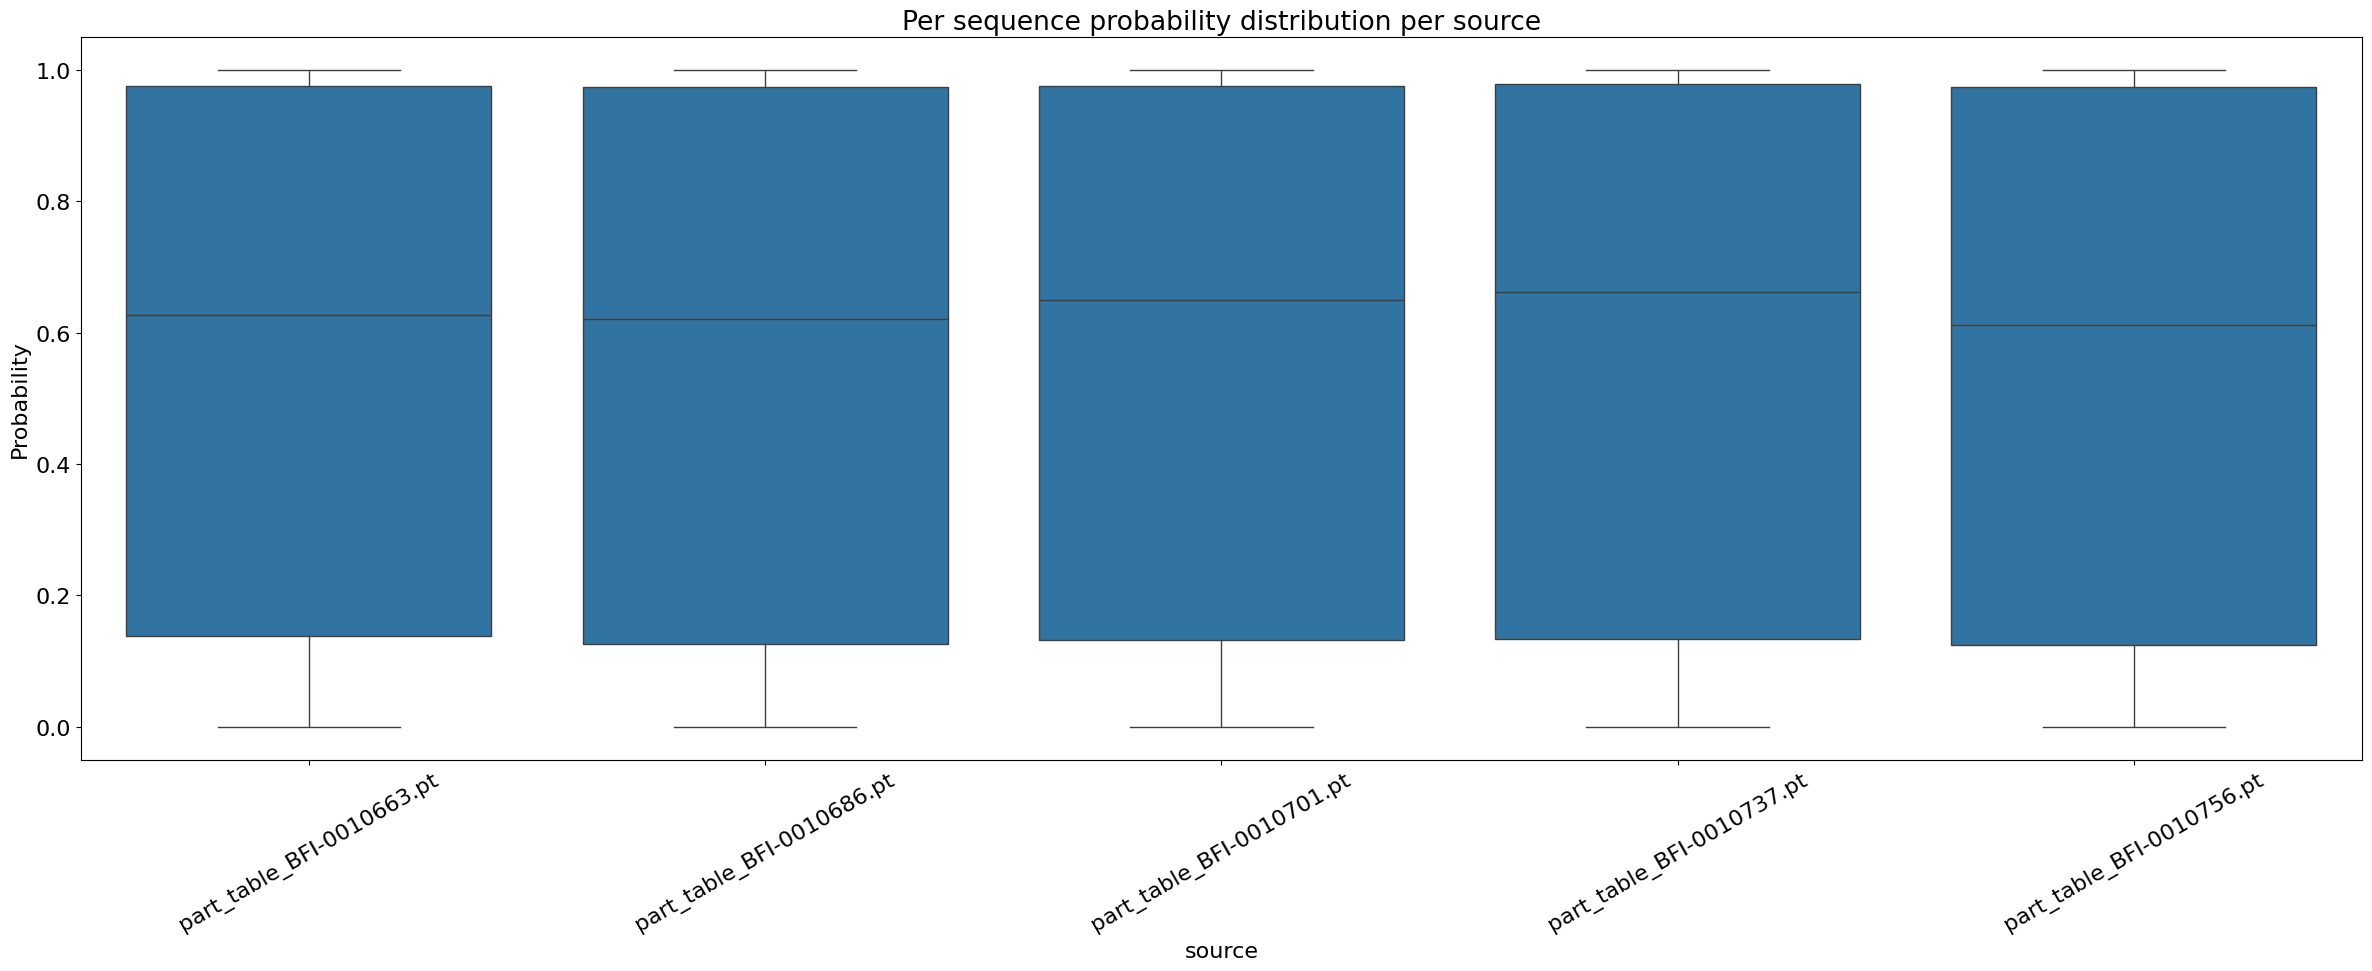

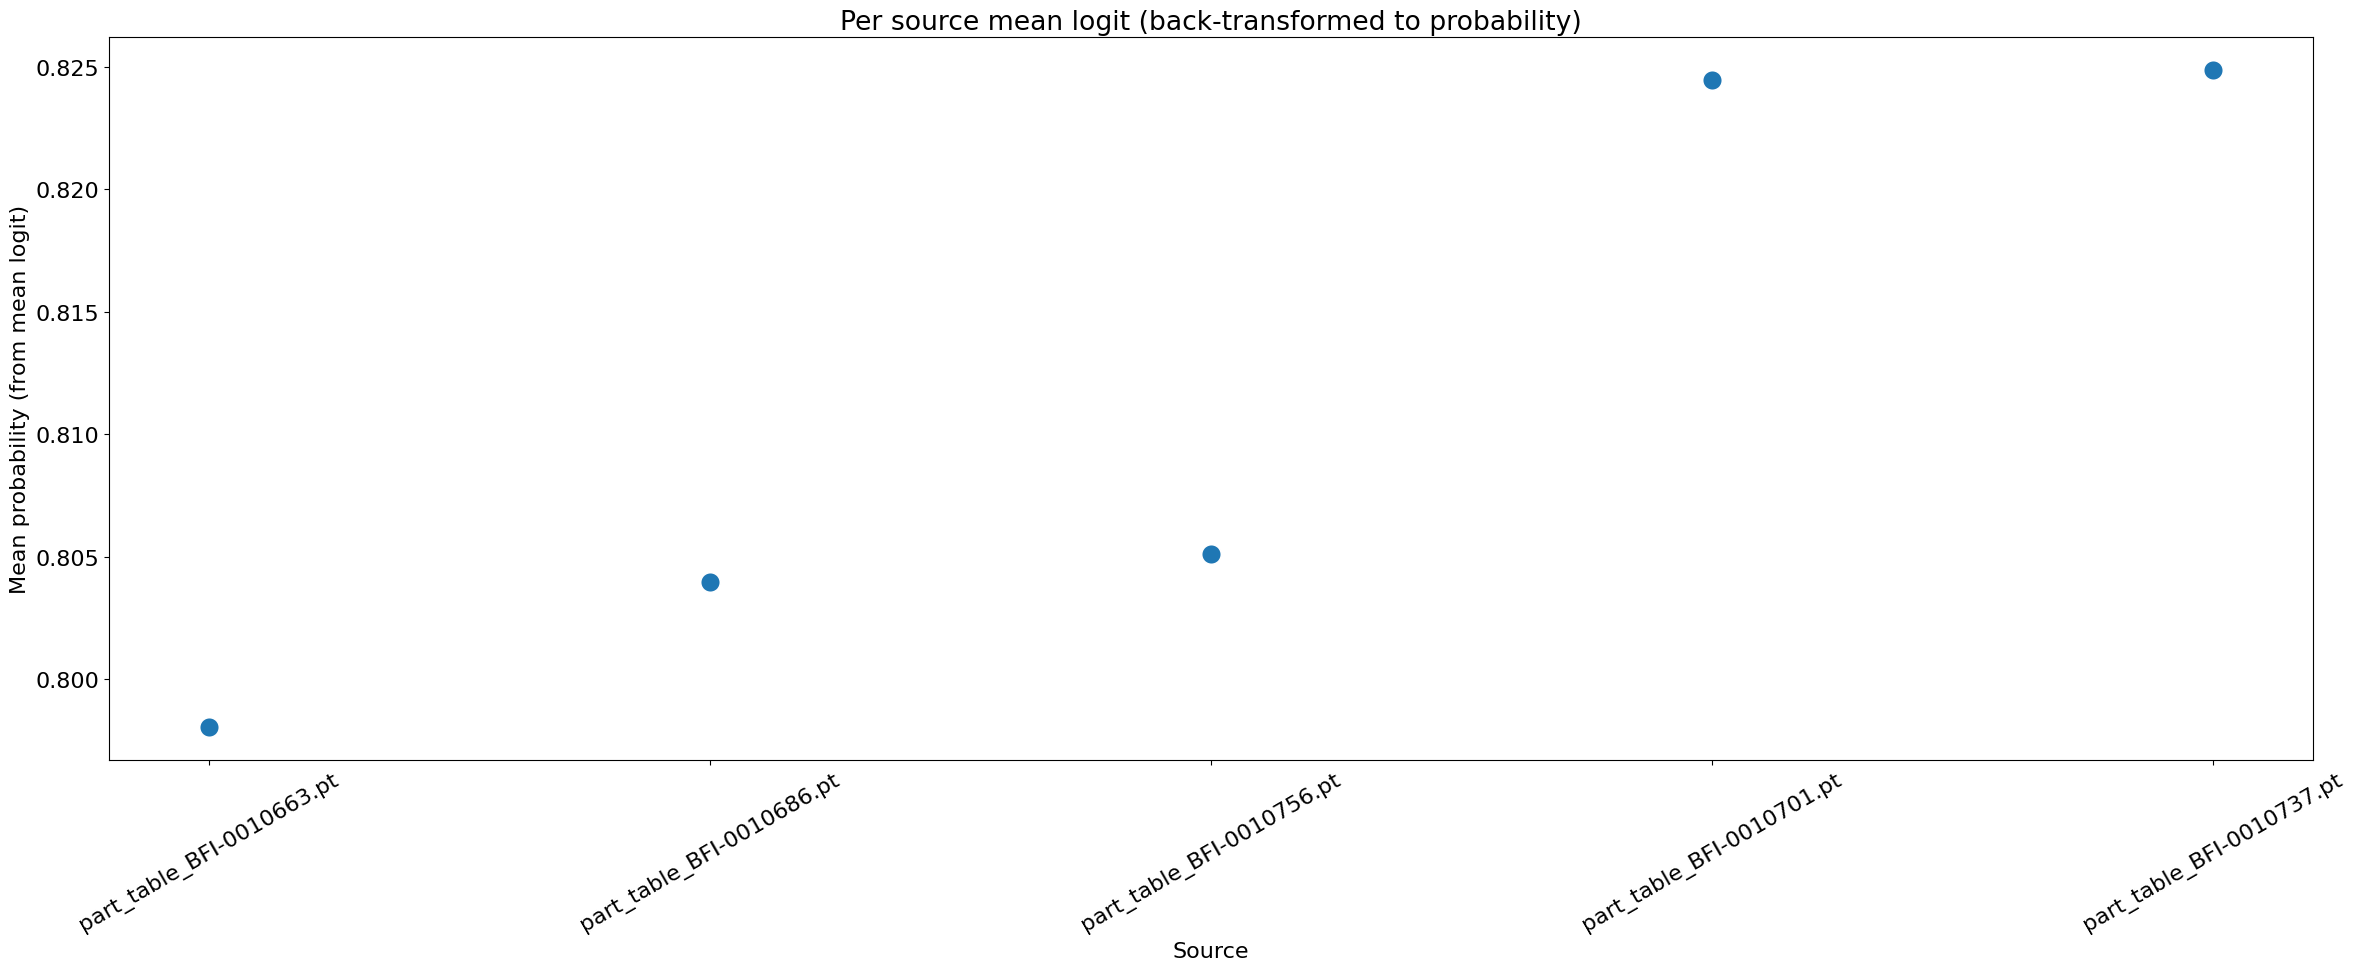

,source,inv_logit_mean
0,part_table_BFI-0010663.pt,0.798064
1,part_table_BFI-0010686.pt,0.803979
2,part_table_BFI-0010756.pt,0.805132
3,part_table_BFI-0010701.pt,0.824475
4,part_table_BFI-0010737.pt,0.824865


In [ ]:
from tcrgnn import plot_inv_logit_per_source
summary_control_df = plot_inv_logit_per_source(control)
summary_control_df

In [21]:
cancer_df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/model_2025_bulk+sc/seekgene_scores/metric_scores.csv")
cancer_df

,Filename,Mean Score,Inv Logit Mean
0,S2_2_cancer_cdr3_scores.txt,0.501919,0.686201
1,S3_1_cancer_cdr3_scores.txt,0.501958,0.680328
2,S1_0_cancer_cdr3_scores.txt,0.517776,0.726123


In [22]:
summary_control_df

,source,inv_logit_mean,label
0,part_table_BFI-0010663.pt,0.798064,0
1,part_table_BFI-0010686.pt,0.803979,0
2,part_table_BFI-0010756.pt,0.805132,0
3,part_table_BFI-0010701.pt,0.824475,0
4,part_table_BFI-0010737.pt,0.824865,0


<Figure size 600x500 with 0 Axes>

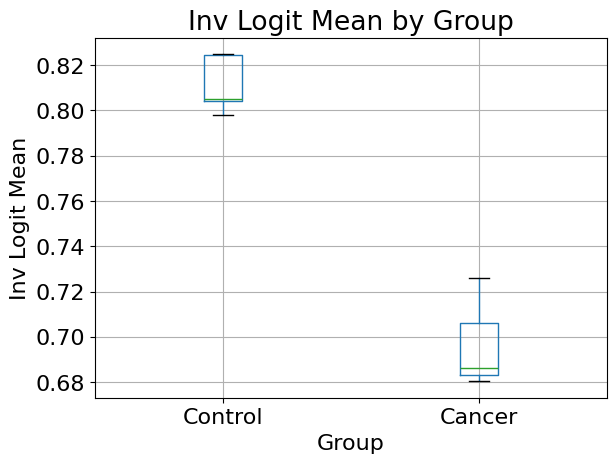

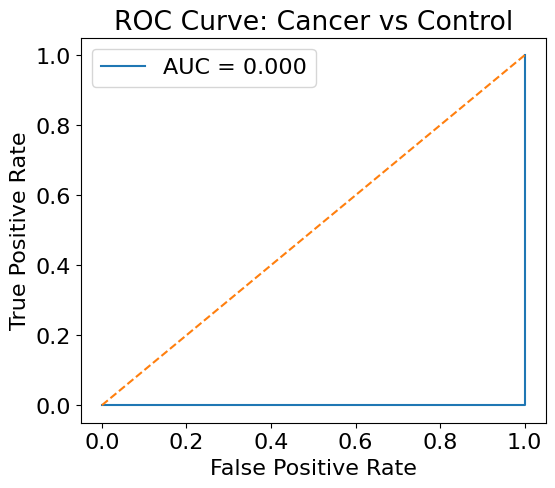

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ------------------------------------------------------
# 1. Standardize column names
# ------------------------------------------------------
# Ensure consistent column names (change if your dataframe uses different names)
cancer_df = cancer_df.rename(columns={
    '# Inv Logit Mean': 'inv_logit_mean',
    'Inv Logit Mean': 'inv_logit_mean'
})

summary_control_df = summary_control_df.rename(columns={
    'inv_logit_mean': 'inv_logit_mean'
})

# ------------------------------------------------------
# 2. Add labels for plotting
# ------------------------------------------------------
cancer_df['label'] = 1
summary_control_df['label'] = 0

combined = pd.concat([cancer_df[['inv_logit_mean', 'label']],
                      summary_control_df[['inv_logit_mean', 'label']]],
                     ignore_index=True)

# ------------------------------------------------------
# 3. Boxplot
# ------------------------------------------------------
plt.figure(figsize=(6, 5))
combined.boxplot(column='inv_logit_mean', by='label')
plt.xticks([1, 2], ['Control', 'Cancer'])
plt.title('Inv Logit Mean by Group')
plt.suptitle('')
plt.xlabel('Group')
plt.ylabel('Inv Logit Mean')
plt.show()

# ------------------------------------------------------
# 4. ROC curve
# ------------------------------------------------------
y_true = combined['label']
y_score = combined['inv_logit_mean']

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Cancer vs Control')
plt.legend()
plt.show()
